Problem Statement:
Predict whether a person’s annual income exceeds $50K based on demographic and work attributes.

Success Criteria:
Achieve > 80% Accuracy or F1-Score on the test set
with proper class imbalance handling and fair feature importance analysis.

Dataset:
Adult (Census Income) Dataset — UCI Machine Learning Repository
🔗 https://archive.ics.uci.edu/ml/datasets/Adult

Problem Type:
Binary Classification

--------------------------------------------------------------
Dataset Summary (Columns & Description)
--------------------------------------------------------------
1. age               → Age of the individual (Numeric)
2. workclass         → Type of employer (Categorical)
3. fnlwgt            → Final weight (Numeric)
4. education         → Highest education level achieved (Categorical)
5. education_num     → Education level encoded numerically (Numeric)
6. marital_status    → Marital status (Categorical)
7. occupation        → Type of occupation (Categorical)
8. relationship      → Family relationship status (Categorical)
9. race              → Race of the individual (Categorical)
10. sex              → Gender (Categorical)
11. capital_gain     → Capital gain in last year (Numeric)
12. capital_loss     → Capital loss in last year (Numeric)
13. hours_per_week   → Hours worked per week (Numeric)
14. native_country   → Country of origin (Categorical)
15. income (target)  → Income class: '>50K' or '<=50K' (Binary Target)

--------------------------------------------------------------
Target Variable:
- Label: income
- Classes:
    - '<=50K' → Low income
    - '>50K'  → High income

Class Imbalance:
≈ 75% of records belong to '<=50K'
≈ 25% belong to '>50K'
Hence, imbalance handling (SMOTE, class weights, etc.) is needed.

--------------------------------------------------------------
 Data Preprocessing Requirements:
1. Handle missing values ('?' → NaN or removal)
2. Encode categorical features (Label/One-Hot Encoding)
3. Convert target: '>50K' → 1 and '<=50K' → 0

--------------------------------------------------------------
Dataset Details:
- Rows: ~32,561 (train), ~16,281 (test)
- Columns: 15 (14 features + 1 target)

SMOTE = Synthetic Minority Oversampling Technique

It’s used when your dataset is imbalanced, meaning one class (e.g. <=50K) has many more samples than the other (>50K).

Example:
75% of people earn <=50K
25% of people earn >50K

If we train directly, the model will mostly predict the majority class (<=50K) and ignore the smaller class.

So, SMOTE helps by:

Creating synthetic (artificial) data points for the minority class using existing samples.

This makes both classes more balanced, so the model learns fairly.

In short:

SMOTE helps the model not to be biased toward the majority class.

Imports libraries

In [ ]:
import pandas as pd  # For handling data in DataFrames, reading/writing CSV/Excel files
import numpy as np   # For numerical operations, arrays, and mathematical functions

import warnings
warnings.filterwarnings("ignore")  # Ignore warning messages

from sklearn.model_selection import train_test_split  # To split data into training and testing sets
from sklearn.preprocessing import StandardScaler       # For feature scaling
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# accuracy_score: evaluates model's classification accuracy
# roc_auc_score: evaluates area under ROC curve
# classification_report: provides precision, recall, f1-score, and support

from sklearn.compose import ColumnTransformer  # For applying different transformations to different columns
from sklearn.preprocessing import OneHotEncoder  # To convert categorical features into numerical (one-hot encoding)
from sklearn.pipeline import Pipeline  # To chain multiple steps (preprocessing + model) together

from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier (ensemble of decision trees)
from xgboost import XGBClassifier  # Extreme Gradient Boosting classifier (efficient and powerful boosting model)

import matplotlib.pyplot as plt  # Basic plotting library
import seaborn as sns  # Advanced statistical plotting and easier visualizations with matplotlib


Load dataset

In [ ]:
cols = [
    'age','workclass','fnlwgt','education','education-num',
    'marital-status','occupation','relationship','race','sex',
    'capital-gain','capital-loss','hours-per-week','native-country','income'
]
df_train = pd.read_csv(
    "/content/adult.data",
    names=cols,
    na_values=" ?",
    skipinitialspace=True
)
df_test = pd.read_csv(
    "/content/adult.test",
    names=cols,
    na_values=" ?",
    skipinitialspace=True,
    skiprows=1   # REMOVE header line
)
# FIX LABELS IN adult.test (remove the ".")
df_test["income"] = df_test["income"].str.replace(".", "", regex=False)

# MERGE BOTH FILES
df = pd.concat([df_train, df_test], ignore_index=True)

print("TRAIN SHAPE:", df_train.shape)
print("TEST SHAPE:", df_test.shape)
print("COMBINED SHAPE:", df.shape)

df.tail(10)


TRAIN SHAPE: (32561, 15)
TEST SHAPE: (16281, 15)
COMBINED SHAPE: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48832,61,Private,89686,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,48,United-States,<=50K
48833,31,Private,440129,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
48834,25,Private,350977,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K
48835,48,Local-gov,349230,Masters,14,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States,<=50K
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K


Clean dataset

In [ ]:
df = df.dropna() # Drop missing rows
# Encode target variable
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

print("Final shape after cleaning:", df.shape)
df.tail(10)


Final shape after cleaning: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48832,61,Private,89686,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,48,United-States,0
48833,31,Private,440129,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0
48834,25,Private,350977,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,0
48835,48,Local-gov,349230,Masters,14,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States,0
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,0
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,0
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,0
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,1


Feature Engineering

In [ ]:
# Age Binning
df["age_bin"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"]
)

# Hours-per-week Category
df["hours_cat"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 20, 40, 60, 100],
    labels=["Part-time", "Full-time", "Over-time", "Extreme"]
)

# Capital Gain Indicator
df["high_cap_gain"] = df["capital-gain"].apply(lambda x: 1 if x > 0 else 0)

# Capital Loss Indicator
df["high_cap_loss"] = df["capital-loss"].apply(lambda x: 1 if x > 0 else 0)

# Total Capital Feature
df["capital_total"] = df["capital-gain"] - df["capital-loss"]

# Combine Workclass into broader groups
df["workclass_group"] = df["workclass"].replace({
    "State-gov": "Gov",
    "Federal-gov": "Gov",
    "Local-gov": "Gov",
    "Self-emp-not-inc": "Self-Employed",
    "Self-emp-inc": "Self-Employed",
    "Private": "Private",
    "?": "Unknown"
})

# Simplify marital status
df["marital_group"] = df["marital-status"].replace({
    "Never-married": "Single",
    "Separated": "Single",
    "Divorced": "Single",
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Widowed": "Single"
})

# Education Levels simplified
df["education_group"] = df["education"].replace({
    "Preschool":"Low",
    "1st-4th":"Low",
    "5th-6th":"Low",
    "7th-8th":"Low",
    "9th":"Medium",
    "10th":"Medium",
    "11th":"Medium",
    "12th":"Medium",
    "HS-grad": "High-School",
    "Some-college": "College",
    "Assoc-acdm": "College",
    "Assoc-voc": "College",
    "Bachelors": "Bachelor",
    "Masters": "Master",
    "Prof-school": "Professional",
    "Doctorate": "PhD"
})

print("Feature Engineering Completed!")


Feature Engineering Completed!


EDA

income
0    37155
1    11687
Name: count, dtype: int64

Percentage Distribution:
income
0    76.071823
1    23.928177
Name: proportion, dtype: float64


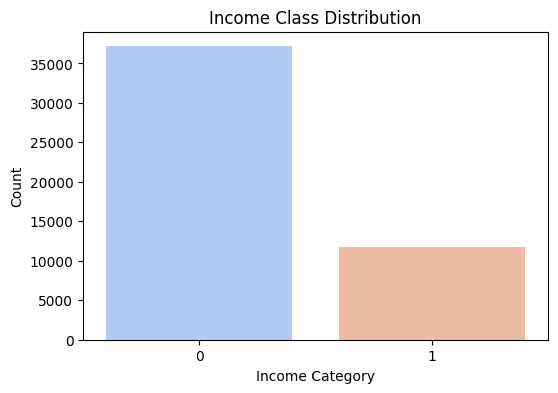

Numerical Columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income', 'high_cap_gain', 'high_cap_loss', 'capital_total']


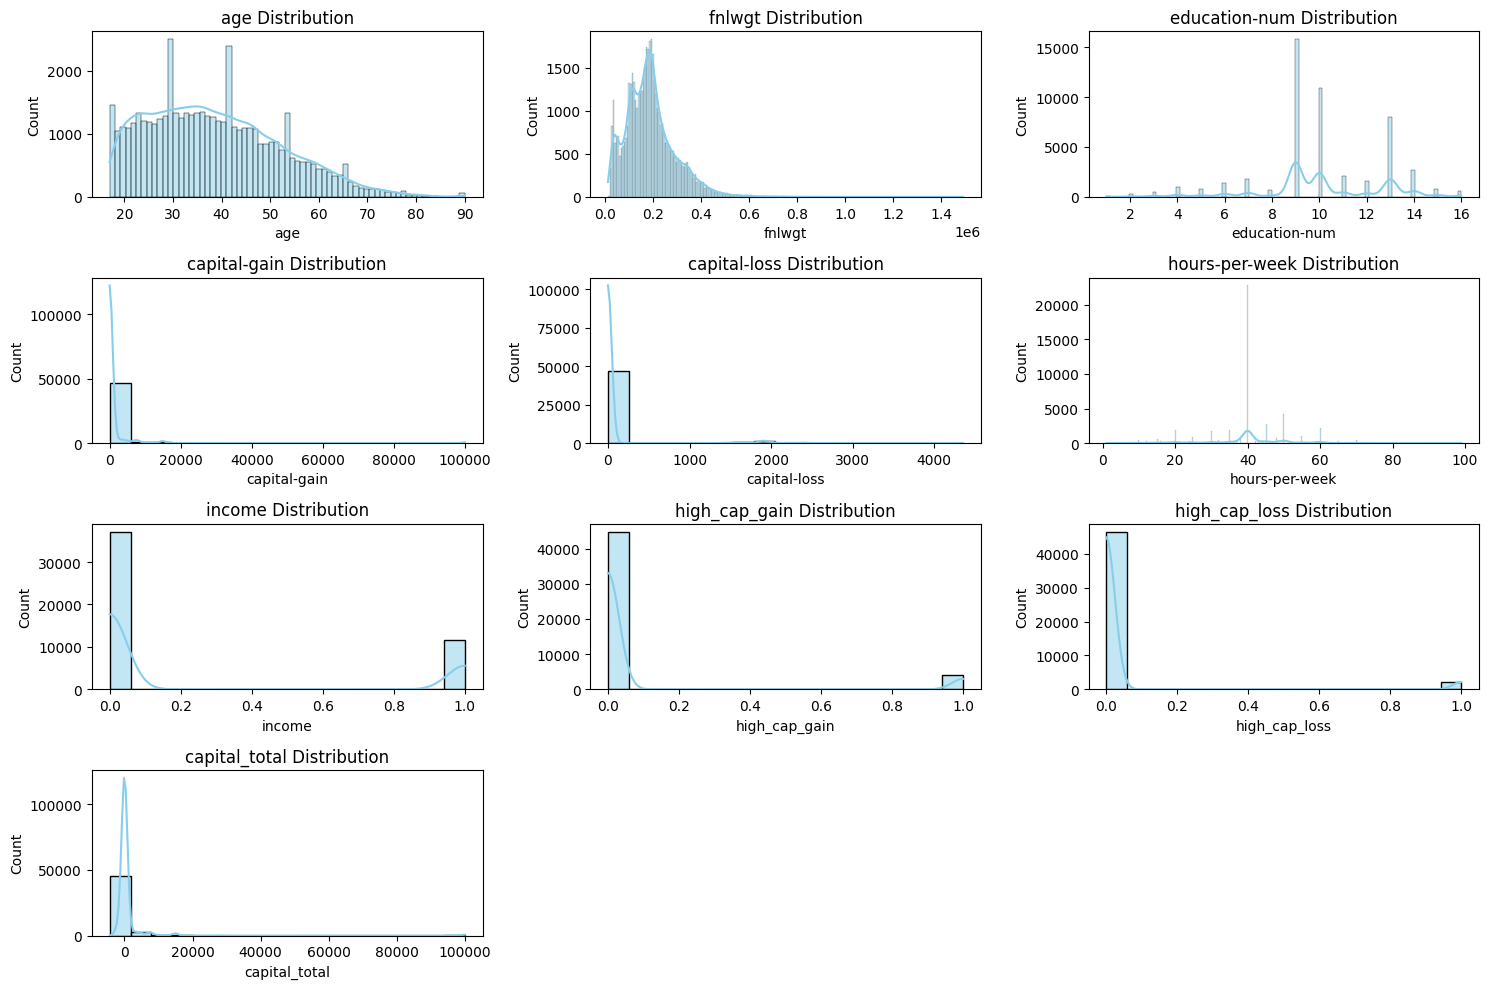

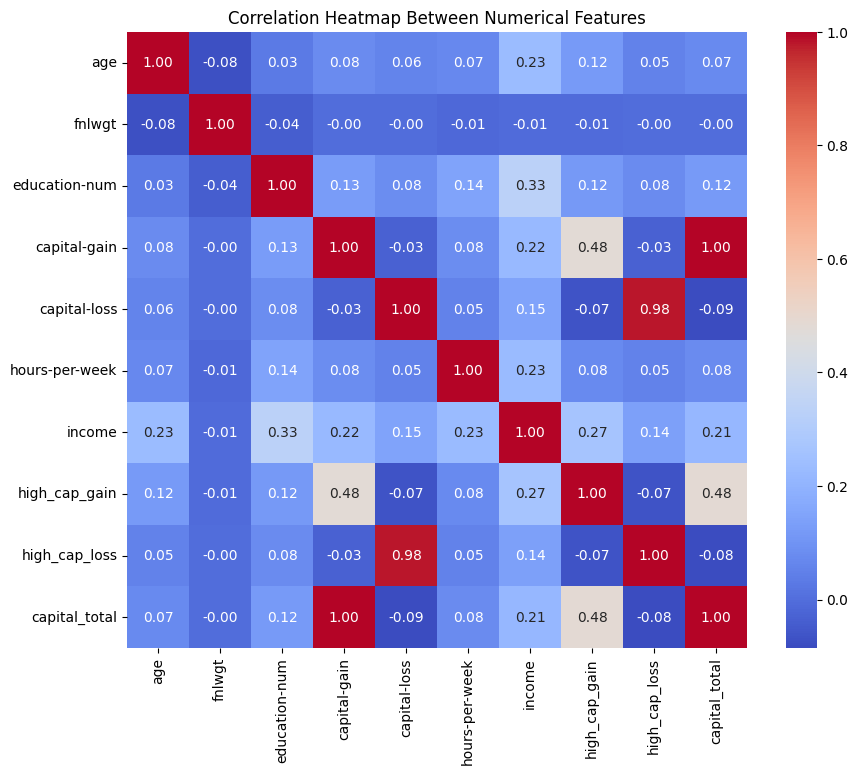

Categorical Columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'workclass_group', 'marital_group', 'education_group']


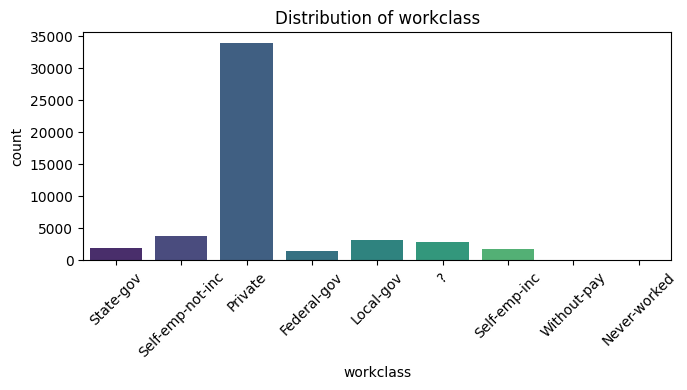

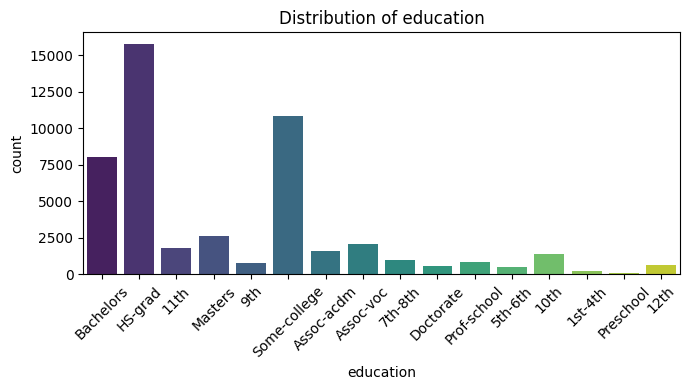

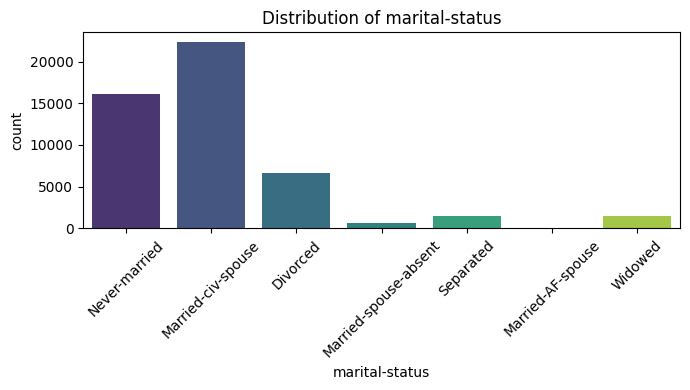

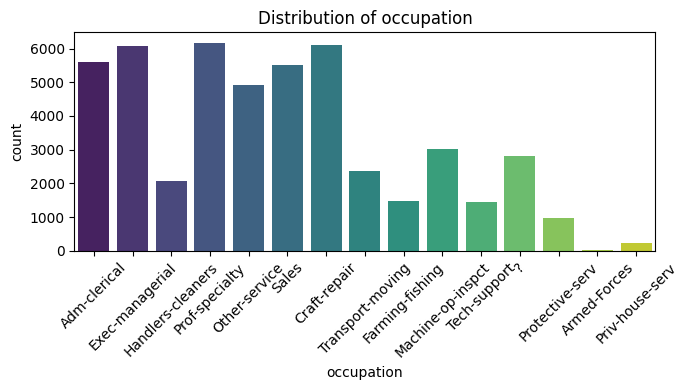

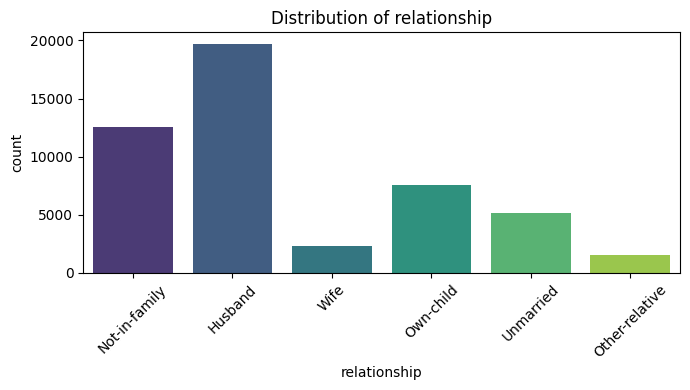

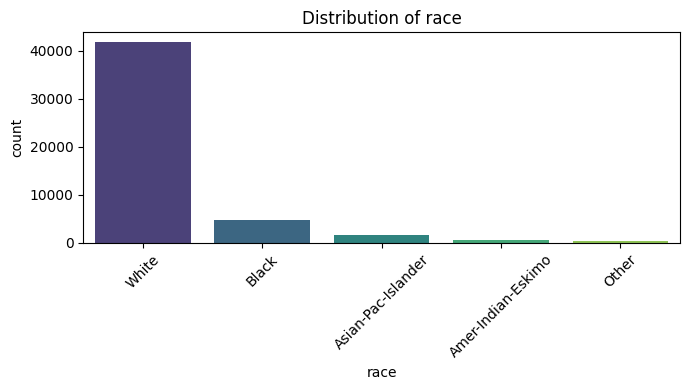

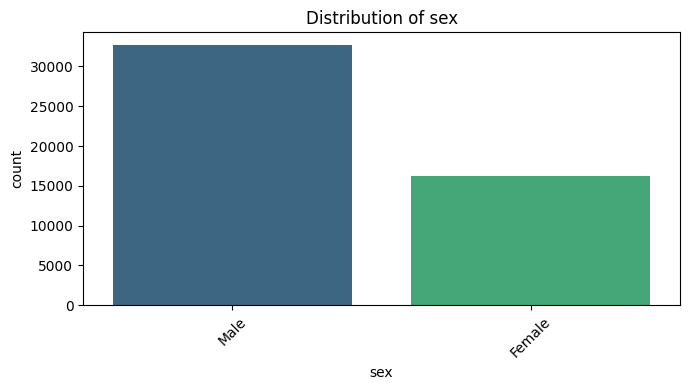

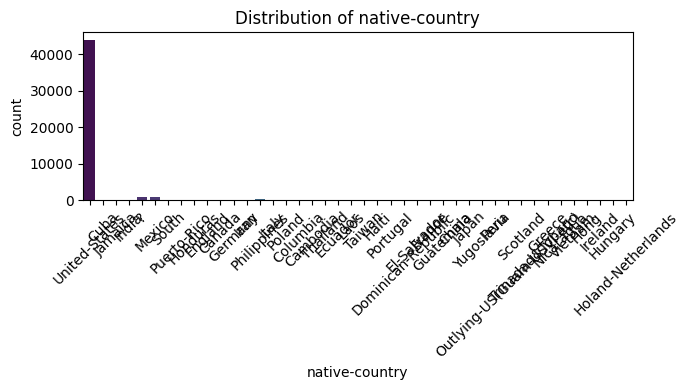

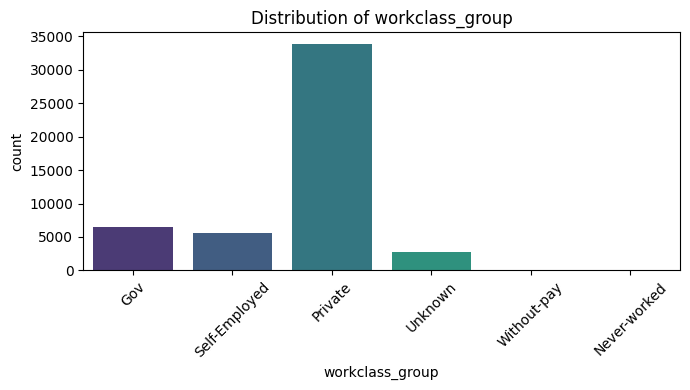

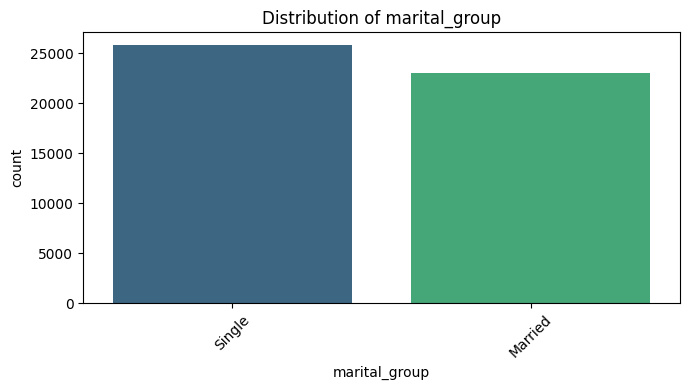

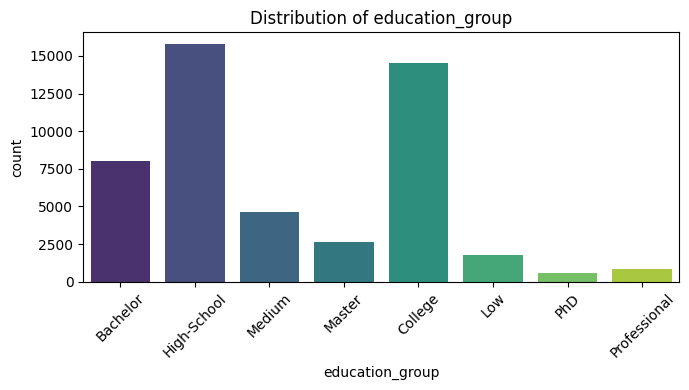

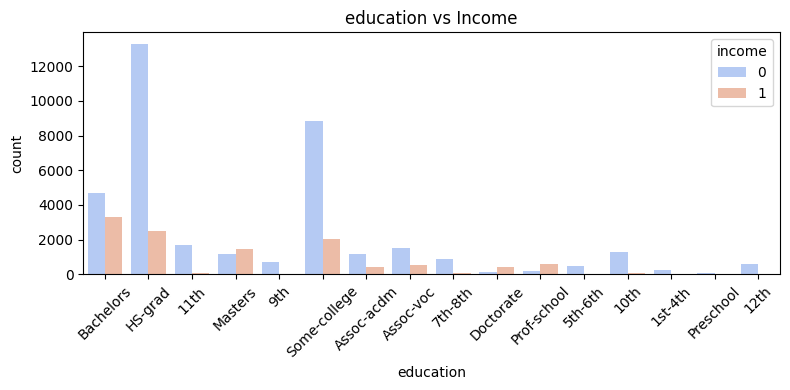

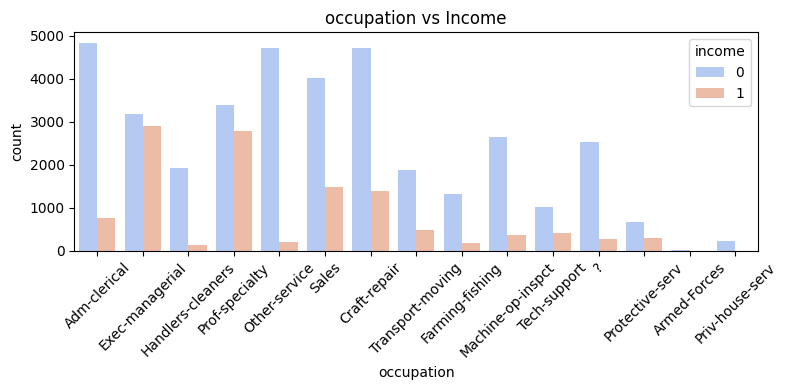

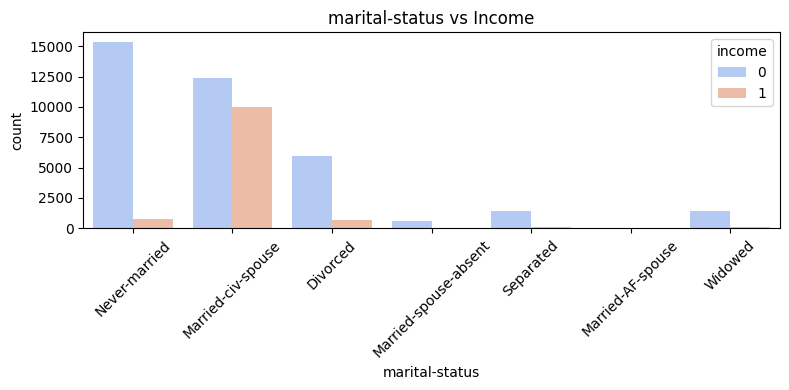

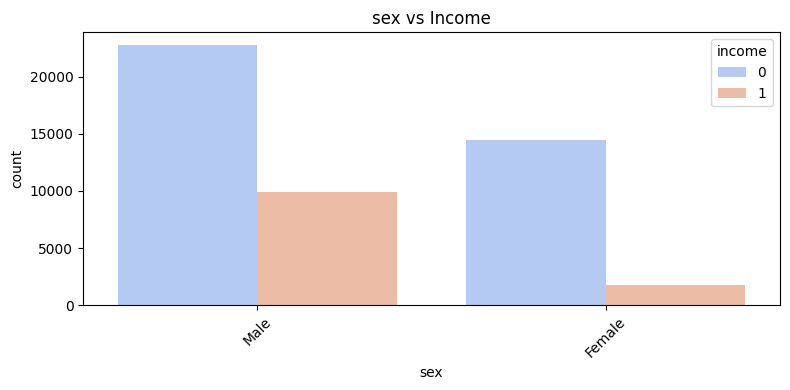

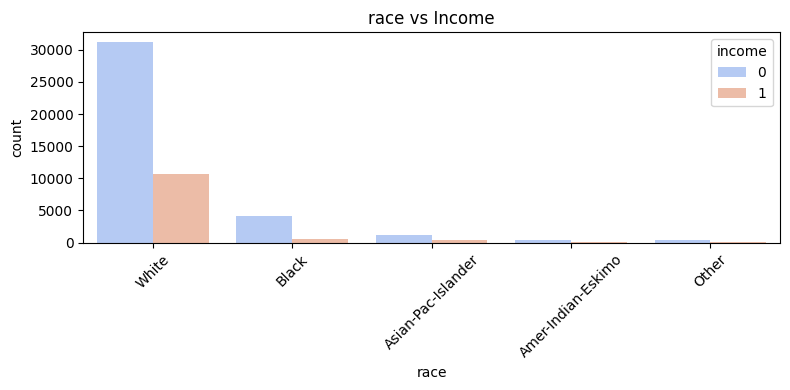

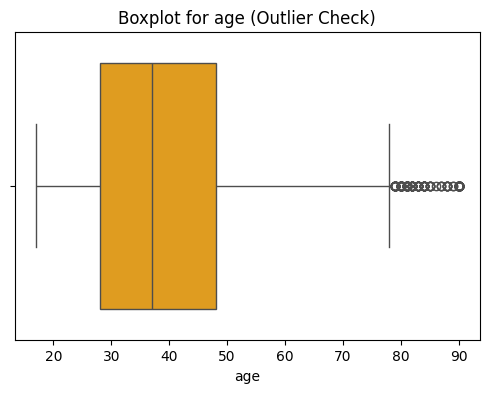

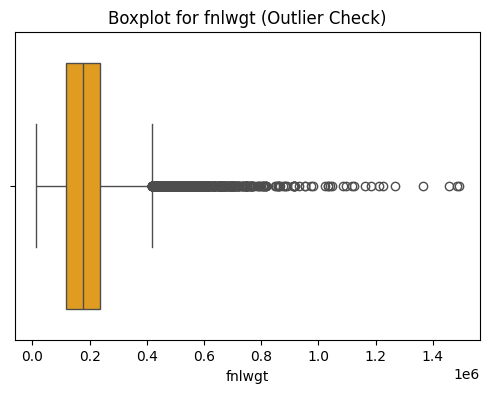

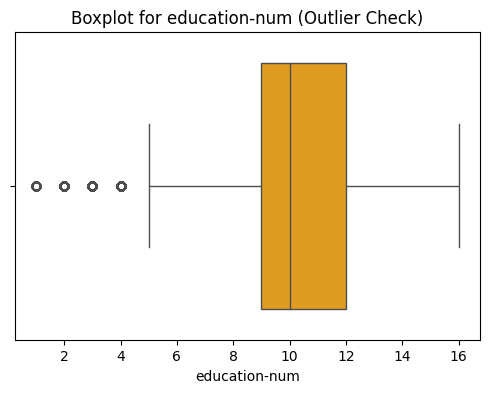

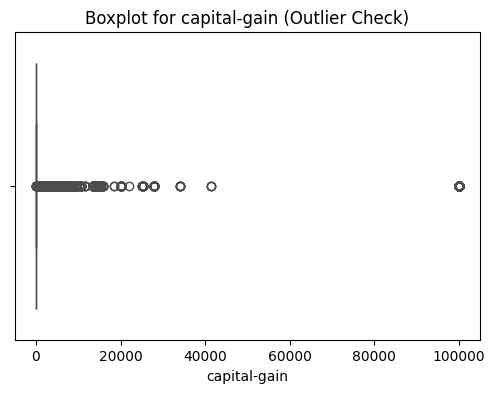

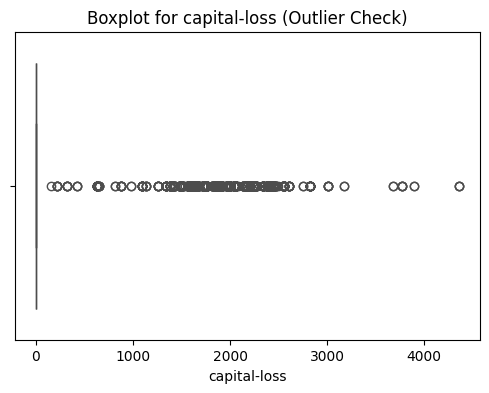

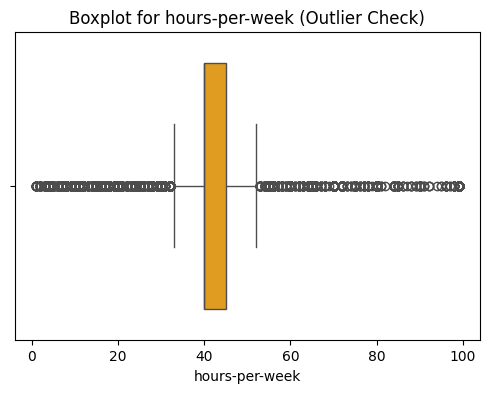

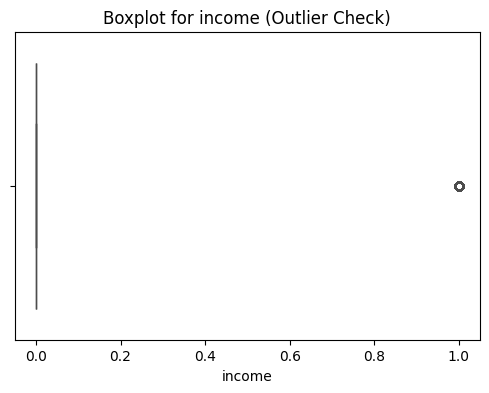

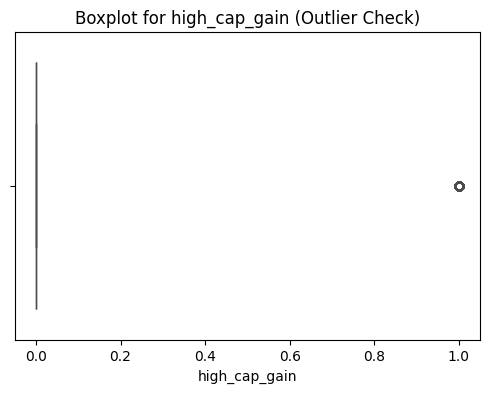

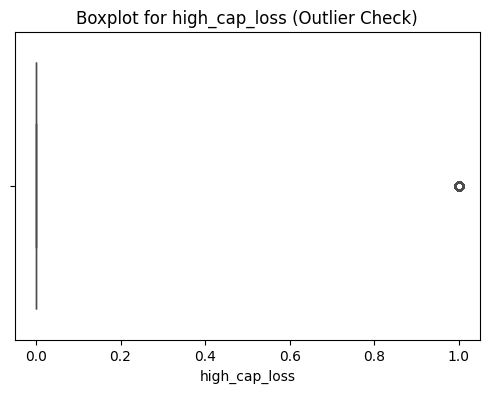

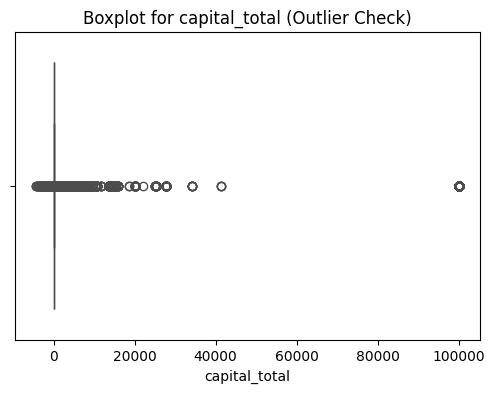

EDA Completed Successfully


In [ ]:
# Target Variable Distribution ('income')
# Shows how many people belong to each income class
data = df
if 'income' in data.columns:
    print(data['income'].value_counts())
    print("\nPercentage Distribution:")
    print(data['income'].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6,4))
    sns.countplot(x='income', data=data, palette='coolwarm')
    plt.title("Income Class Distribution")
    plt.xlabel("Income Category")
    plt.ylabel("Count")
    plt.show()

# Numerical Columns Distribution
# Displays how numeric values are spread (to detect skewness or outliers)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical Columns: {num_cols}")

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.histplot(data[col], kde=True, color='skyblue')
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Correlation Heatmap
# Helps find relationships between numerical features
plt.figure(figsize=(10,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Between Numerical Features")
plt.show()

# Categorical Feature Distributions
# Shows frequency of each category for better understanding of data
cat_cols = data.select_dtypes(include='object').columns.tolist()
if 'income' in cat_cols:
    cat_cols.remove('income')
print(f"Categorical Columns: {cat_cols}")

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=data, palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Relationship Between Features and Target
# Compares key categorical variables with income to see which affect income levels
important_cats = ['education', 'occupation', 'marital-status', 'sex', 'race']
for col in important_cats:
    if col in data.columns:
        plt.figure(figsize=(8,4))
        sns.countplot(x=col, hue='income', data=data, palette="coolwarm")
        plt.title(f"{col} vs Income")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Boxplots for Outlier Detection
# Shows which numeric features contain outliers
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col], color='orange')
    plt.title(f"Boxplot for {col} (Outlier Check)")
    plt.show()

print("EDA Completed Successfully")


Feature Split

In [ ]:
X = df.drop("income", axis=1)
y = df["income"]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

numeric_features, categorical_features


(Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
        'hours-per-week', 'high_cap_gain', 'high_cap_loss', 'capital_total'],
       dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country', 'age_bin', 'hours_cat',
        'workclass_group', 'marital_group', 'education_group'],
       dtype='object'))

Train/Val/Test Split

In [ ]:
#Train set → used to fit the model
#Validation set → used to tune hyperparameters and check performance during training
#Test set → used to evaluate the final model on unseen data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (34189, 22)
Validation: (7326, 22)
Test: (7327, 22)


SMOTENC

Before SMOTE: income
0    26008
1     8181
Name: count, dtype: int64
After SMOTE: income
0    26008
1    26008
Name: count, dtype: int64


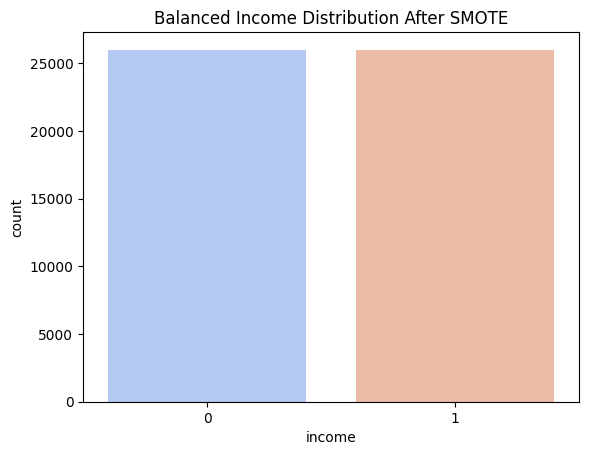

In [ ]:
from imblearn.over_sampling import SMOTENC

cat_features_index = [X.columns.get_loc(col) for col in categorical_features]

sm = SMOTENC(categorical_features=cat_features_index, random_state=42)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())
#Visualize balanced target
sns.countplot(x=y_train_resampled, palette="coolwarm")
plt.title("Balanced Income Distribution After SMOTE")
plt.show()


Preprocessing Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features)
    ]
)


Define Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

results = {}
models


{'Logistic Regression': LogisticRegression(max_iter=500),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=None,
               num_parallel_tree=None, ...)}

Train + Validate Models

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_resampled, y_train_resampled)


    val_pred = pipeline.predict(X_val)
    val_proba = pipeline.predict_proba(X_val)[:, 1]
#AUC (Area Under Curve) → measures how well model ranks high-income people higher than low-income people
#Accuracy → percentage of correct predictions
    auc = roc_auc_score(y_val, val_proba)
    acc = accuracy_score(y_val, val_pred)

    results[name] = {"AUC": auc, "Accuracy": acc, "Model": pipeline}

    print(f"{name} Validation AUC: {auc:.4f}")
    print(f"{name} Validation Accuracy: {acc:.4f}")



Training Logistic Regression...
Logistic Regression Validation AUC: 0.9123
Logistic Regression Validation Accuracy: 0.8387

Training Random Forest...
Random Forest Validation AUC: 0.9045
Random Forest Validation Accuracy: 0.8514

Training XGBoost...
XGBoost Validation AUC: 0.9282
XGBoost Validation Accuracy: 0.8705


ROC Curves + Confusion Matrices

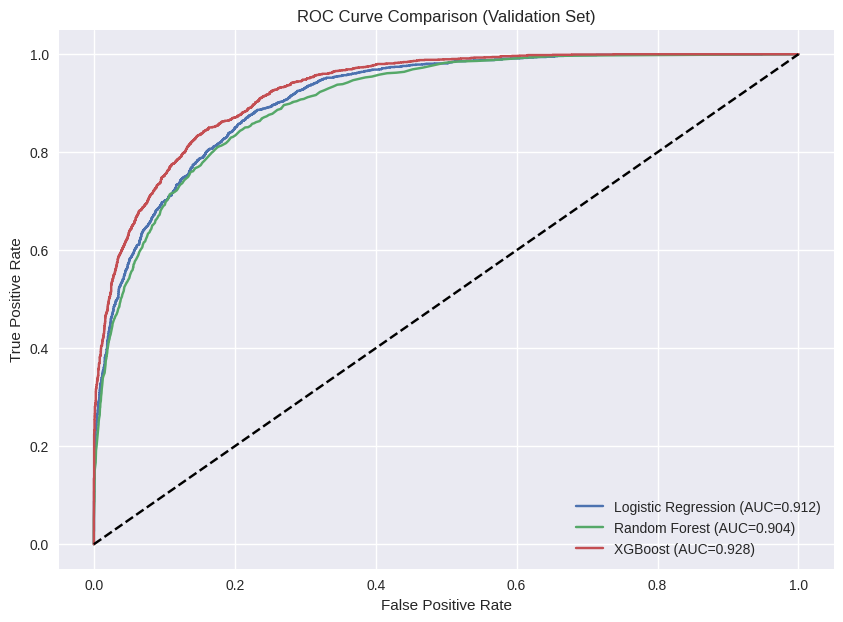

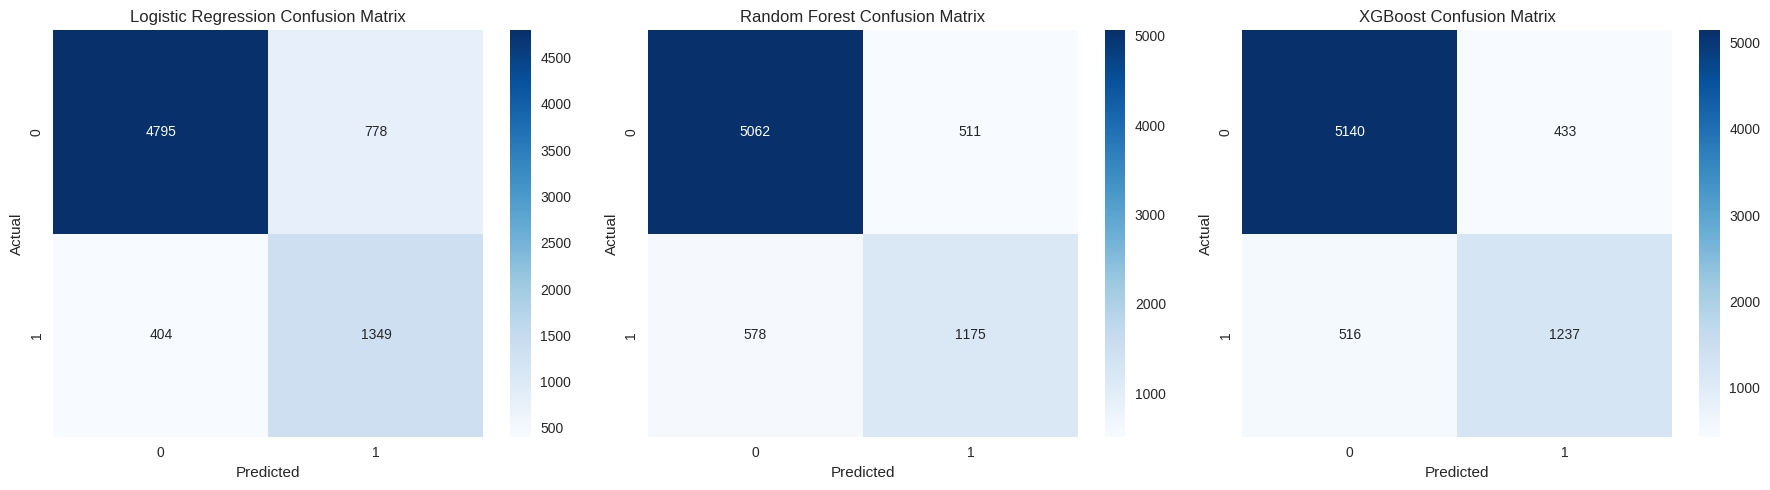

In [ ]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

#roc_curve → computes False Positive Rate (FPR) and True Positive Rate (TPR) for plotting ROC curves
plt.figure(figsize=(10, 7))
for name, result in results.items():
    model = result["Model"]
    val_proba = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, val_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['AUC']:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

# CONFUSION MATRIX
plt.figure(figsize=(18, 5))

for i, (name, result) in enumerate(results.items(), 1):
    model = result["Model"]
    val_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, val_pred)

    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()
#|          | Pred 0 | Pred 1 |
#| ---------| ------ | ------ |
#| Actual 0 | TN     | FP     |
#| Actual 1 | FN     | TP     |


Select Best Model

In [ ]:
best_model_name = max(results, key=lambda x: results[x]["AUC"])
best_model = results[best_model_name]["Model"]

print("\nBEST MODEL:", best_model_name)
print("AUC:", results[best_model_name]["AUC"])



BEST MODEL: XGBoost
AUC: 0.9281901605911231


Test Set Performance

In [ ]:
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:,1]

print("\nTEST SET RESULTS")
print("AUC:", roc_auc_score(y_test, test_proba))
print("Accuracy:", accuracy_score(y_test, test_pred))
print("\nClassification Report:\n", classification_report(y_test, test_pred))



TEST SET RESULTS
AUC: 0.9245329806241225
Accuracy: 0.8670670124198171

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91      5574
           1       0.73      0.71      0.72      1753

    accuracy                           0.87      7327
   macro avg       0.82      0.81      0.82      7327
weighted avg       0.87      0.87      0.87      7327



Precision

Of all predictions that the model said >50K, 73% were correct

High precision → few false positives

Recall

Of all actual >50K people, the model correctly identified 71%

High recall → few false negatives

F1-Score

Balance between precision and recall

Class 1 F1 = 0.72 → good balance, but still slightly lower than class 0

Support

Number of samples in each class

5574 for <=50K (majority), 1753 for >50K (minority)

Feature Importance


Feature Importance for XGBoost


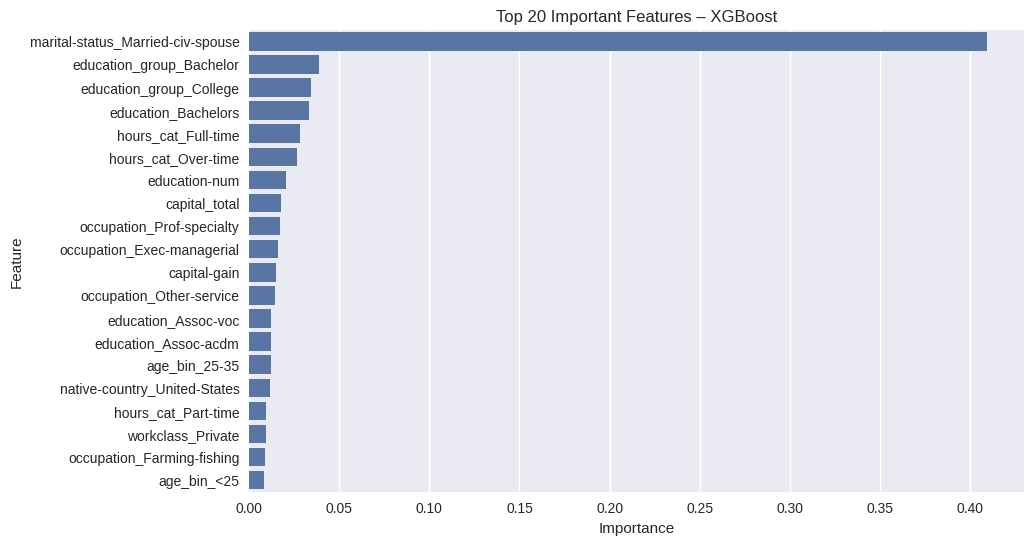

In [ ]:
if best_model_name in ["Random Forest", "XGBoost"]:
    print(f"\nFeature Importance for {best_model_name}")

    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]
    ohe_features = ohe.get_feature_names_out(categorical_features)

    final_features = list(numeric_features) + list(ohe_features)

    importances = best_model.named_steps["model"].feature_importances_

    fi = pd.DataFrame({
        "Feature": final_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(x="Importance", y="Feature", data=fi)
    plt.title(f"Top 20 Important Features – {best_model_name}")
    plt.show()
